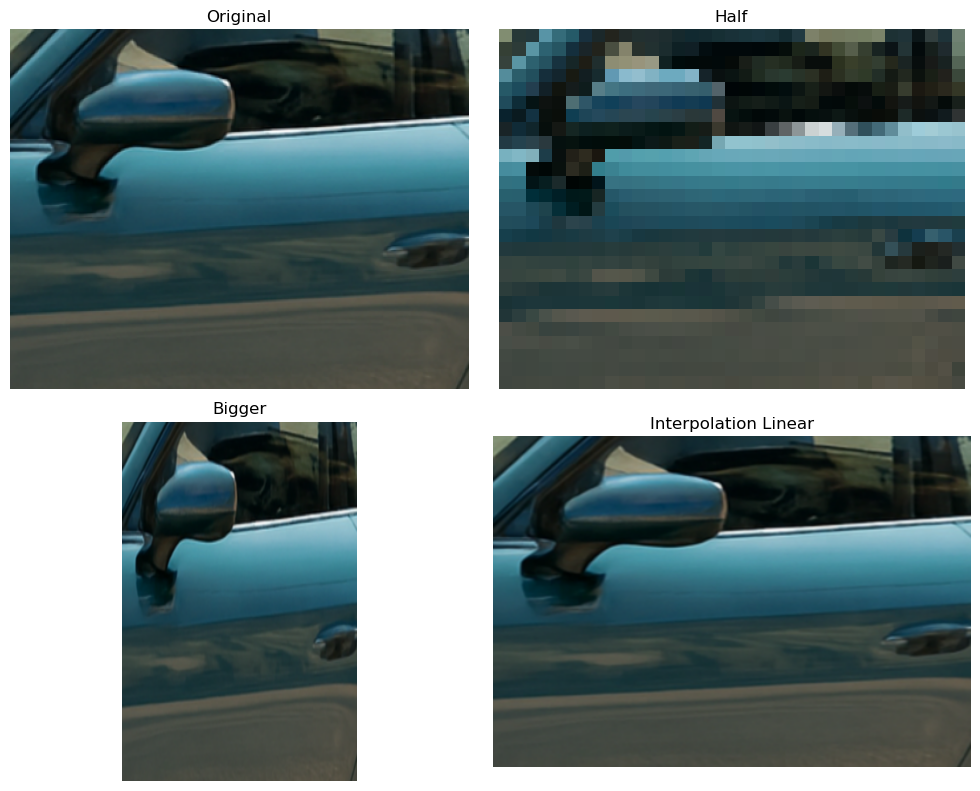

In [6]:
import cv2
import matplotlib.pyplot as plt
import os

# Image path
image_path = r"C:\Users\vatap\OneDrive\Pictures\car.png.png"

# Check if image exists
if not os.path.exists(image_path):
    print("Image not found!")
else:
    # Load image
    image = cv2.imread(image_path, 1)

    if image is None:
        print("OpenCV could not load the image!")
    else:
        # Resize operations
        half = cv2.resize(image, (0, 0), fx=0.1, fy=0.1)

        bigger = cv2.resize(image, (1050, 1610))

        stretch_near = cv2.resize(
            image,
            (780, 540),
            interpolation=cv2.INTER_LINEAR
        )

        # Titles
        Titles = [
            "Original",
            "Half",
            "Bigger",
            "Interpolation Linear"
        ]

        # Image list
        images = [
            image,
            half,
            bigger,
            stretch_near
        ]

        # Display images
        plt.figure(figsize=(10, 8))

        for i in range(4):
            plt.subplot(2, 2, i + 1)
            plt.title(Titles[i])

            # Convert BGR to RGB for correct colors
            plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))

            plt.axis("off")

        plt.tight_layout()
        plt.show()

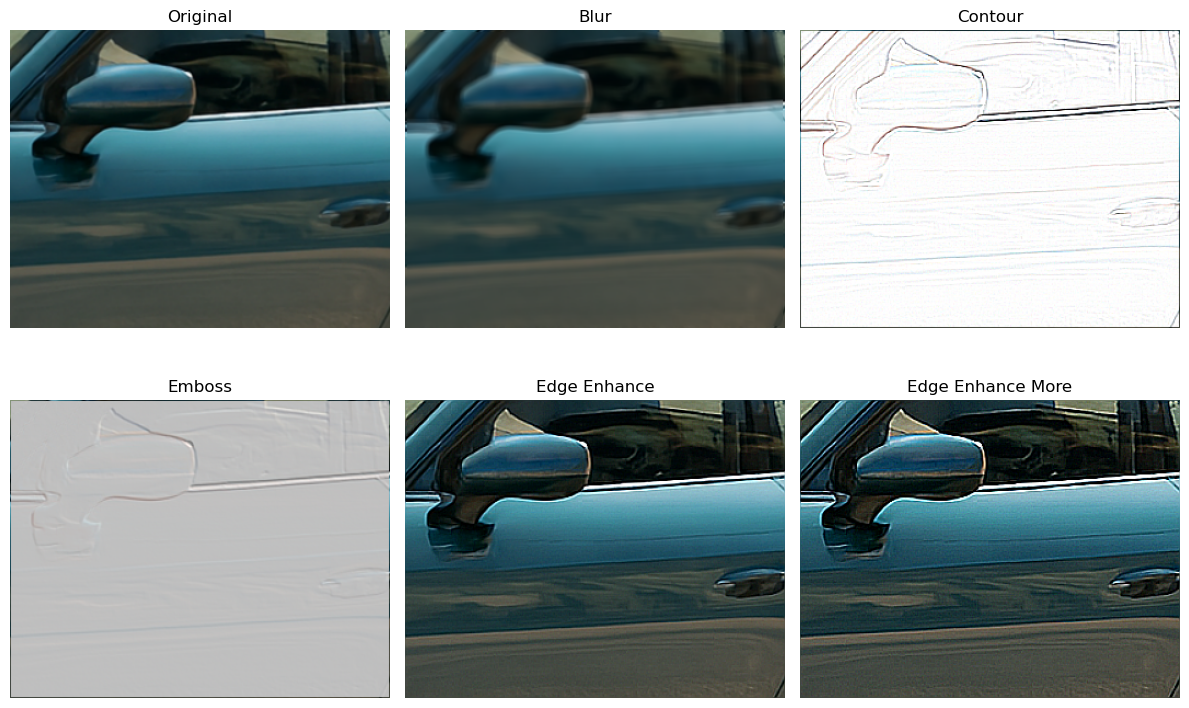

In [8]:
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt

im1 = Image.open(r"C:\Users\vatap\OneDrive\Pictures\car.png.png")

images = [
    im1,
    im1.filter(ImageFilter.BLUR),
    im1.filter(ImageFilter.CONTOUR),
    im1.filter(ImageFilter.EMBOSS),
    im1.filter(ImageFilter.EDGE_ENHANCE),
    im1.filter(ImageFilter.EDGE_ENHANCE_MORE)
]

titles = [
    "Original",
    "Blur",
    "Contour",
    "Emboss",
    "Edge Enhance",
    "Edge Enhance More"
]

plt.figure(figsize=(12, 8))

for i in range(len(images)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

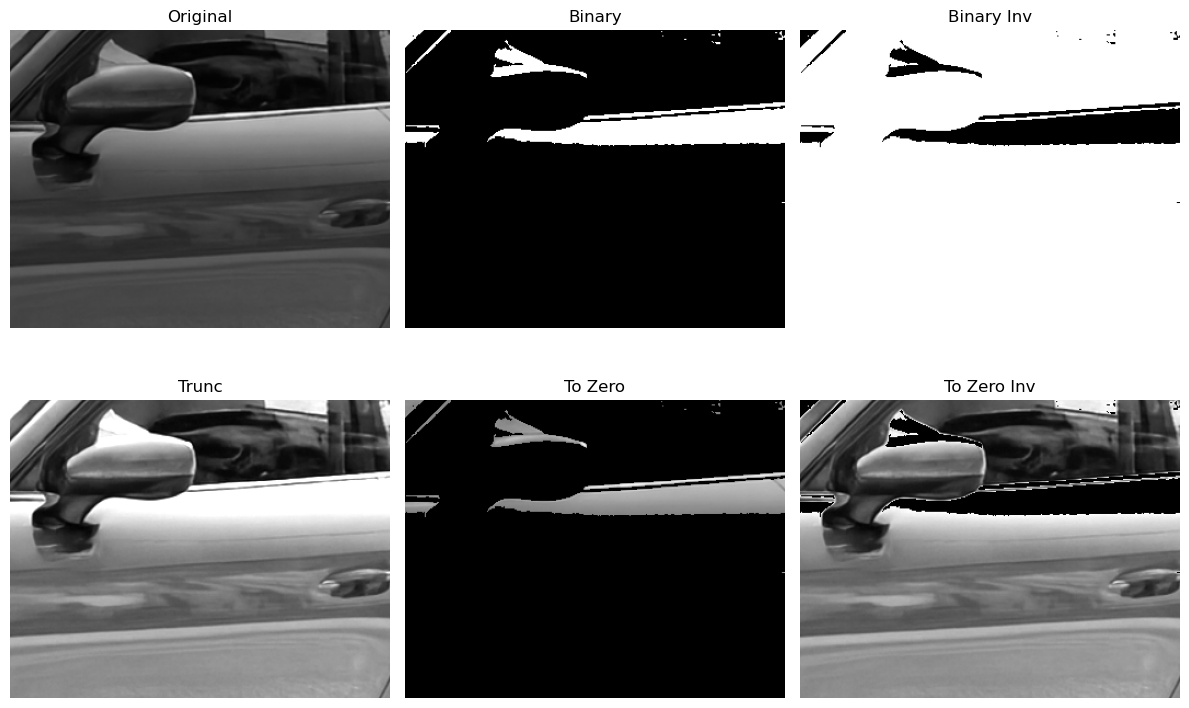

In [9]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(r"C:\Users\vatap\OneDrive\Pictures\car.png.png")

img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
_, thresh1 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
_, thresh2 = cv2.threshold(img, 127, 255, cv2.THRESH_TRUNC)
_, thresh3 = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO)
_, thresh4 = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO_INV)

titles = [
    'Original',
    'Binary',
    'Binary Inv',
    'Trunc',
    'To Zero',
    'To Zero Inv'
]

images = [
    img,
    thresh,
    thresh1,
    thresh2,
    thresh3,
    thresh4
]

plt.figure(figsize=(12, 8))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

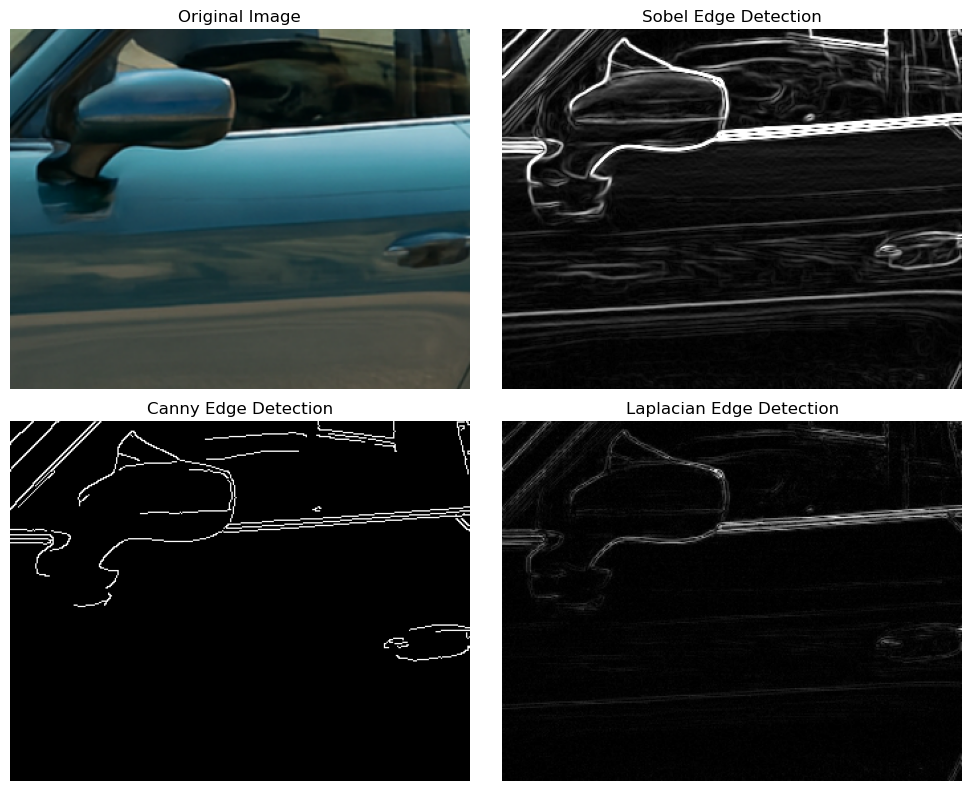

In [10]:
import cv2
import matplotlib.pyplot as plt

# Load image
image = cv2.imread(r"C:\Users\vatap\OneDrive\Pictures\car.png.png")

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Sobel
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobel_x, sobel_y)
sobel_combined = cv2.convertScaleAbs(sobel_combined)

# Canny
canny = cv2.Canny(gray, 100, 200)

# Laplacian
laplacian = cv2.Laplacian(gray, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)

# Convert original image to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

titles = [
    "Original Image",
    "Sobel Edge Detection",
    "Canny Edge Detection",
    "Laplacian Edge Detection"
]

images = [
    image_rgb,
    sobel_combined,
    canny,
    laplacian
]

plt.figure(figsize=(10, 8))

for i in range(4):
    plt.subplot(2, 2, i + 1)

    if i == 0:
        plt.imshow(images[i])
    else:
        plt.imshow(images[i], cmap='gray')

    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

Number of contours detected: 35


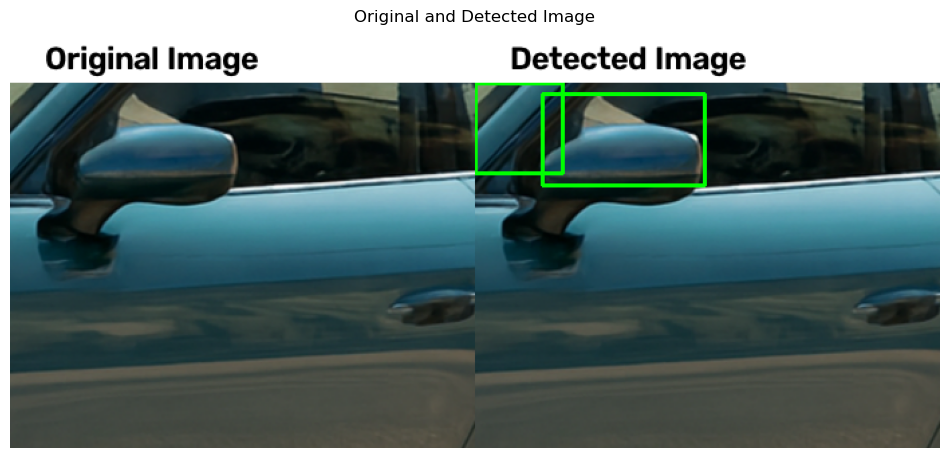

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
image = cv2.imread(r"C:\Users\vatap\OneDrive\Pictures\car.png.png")

if image is None:
    print("Image not found.")
else:
    # Make a copy of the original image
    original_image = image.copy()

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian Blur
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Edge Detection
    edges = cv2.Canny(blurred, 30, 100)

    # Find Contours
    contours, _ = cv2.findContours(
        edges.copy(),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    print("Number of contours detected:", len(contours))

    # Draw Bounding Boxes
    for contour in contours:

        if cv2.contourArea(contour) < 50:
            continue

        x, y, w, h = cv2.boundingRect(contour)

        cv2.rectangle(
            image,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

    # Combine original and detected images
    side_by_side = np.hstack((original_image, image))

    # Create Header
    header_height = 40

    header = np.ones(
        (header_height, side_by_side.shape[1], 3),
        dtype=np.uint8
    ) * 255

    # Add Labels
    font = cv2.FONT_HERSHEY_SIMPLEX

    half_width = original_image.shape[1]

    cv2.putText(
        header,
        "Original Image",
        (int(half_width * 0.25) - 60, 30),
        font,
        0.8,
        (0, 0, 0),
        2
    )

    cv2.putText(
        header,
        "Detected Image",
        (int(half_width * 1.25) - 60, 30),
        font,
        0.8,
        (0, 0, 0),
        2
    )

    # Final Output
    final_output = np.vstack((header, side_by_side))

    # Convert BGR to RGB
    final_output = cv2.cvtColor(
        final_output,
        cv2.COLOR_BGR2RGB
    )

    # Display in Jupyter Notebook
    plt.figure(figsize=(12, 6))
    plt.imshow(final_output)
    plt.axis("off")
    plt.title("Original and Detected Image")
    plt.show()

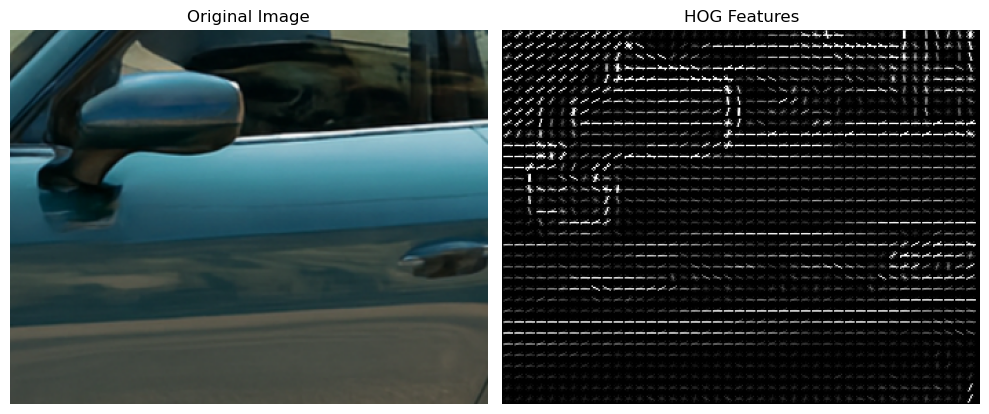

HOG Feature Descriptor Shape: (49896,)
Total HOG Features: 49896


In [12]:
from skimage.io import imread
from skimage.feature import hog
from skimage import exposure
import matplotlib.pyplot as plt

# Load image
img = imread(r"C:\Users\vatap\OneDrive\Pictures\car.png.png")

# Compute HOG features
fd, hog_image = hog(
    img,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True,
    channel_axis=-1
)

# Improve HOG image visibility
hog_image_rescaled = exposure.rescale_intensity(
    hog_image,
    in_range=(0, 10)
)

# Display Original and HOG images
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(10, 5),
    sharex=True,
    sharey=True
)

ax1.imshow(img)
ax1.set_title("Original Image")
ax1.axis("off")

ax2.imshow(hog_image_rescaled, cmap="gray")
ax2.set_title("HOG Features")
ax2.axis("off")

plt.tight_layout()
plt.show()

print("HOG Feature Descriptor Shape:", fd.shape)
print("Total HOG Features:", len(fd))

Number of keypoints detected: 109
Descriptor shape: (109, 128)


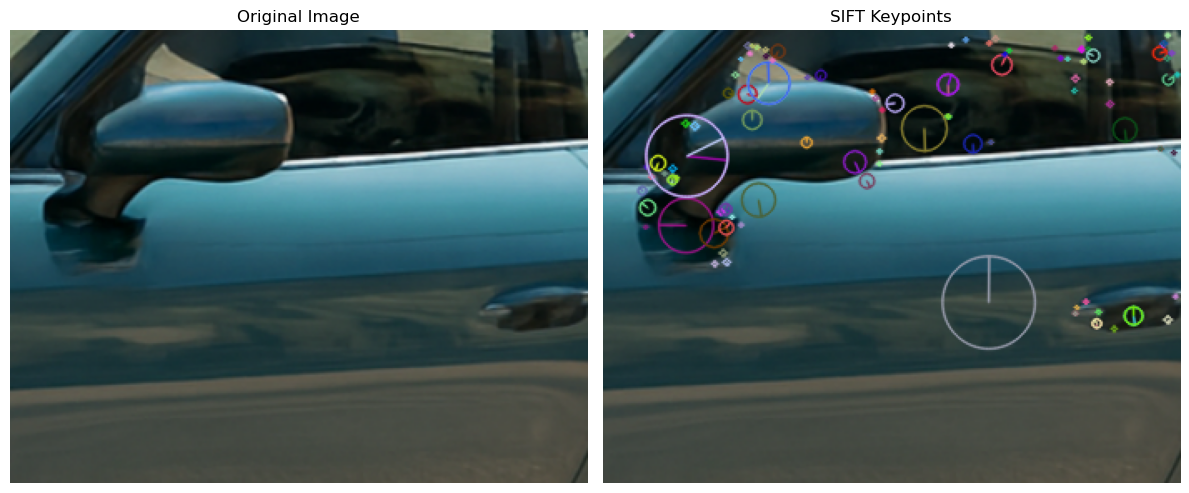

In [13]:
import cv2
import matplotlib.pyplot as plt

# Load image
image = cv2.imread(r"C:\Users\vatap\OneDrive\Pictures\car.png.png")

if image is None:
    print("Image not found.")
else:
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Create SIFT detector
    sift = cv2.SIFT_create()

    # Detect keypoints and descriptors
    keypoints, descriptors = sift.detectAndCompute(gray, None)

    print("Number of keypoints detected:", len(keypoints))

    if descriptors is not None:
        print("Descriptor shape:", descriptors.shape)
    else:
        print("No descriptors found.")

    # Draw keypoints
    sift_image = cv2.drawKeypoints(
        image,
        keypoints,
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    # Convert BGR to RGB for matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    sift_image_rgb = cv2.cvtColor(sift_image, cv2.COLOR_BGR2RGB)

    # Display images
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    ax1.imshow(image_rgb)
    ax1.set_title("Original Image")
    ax1.axis("off")

    ax2.imshow(sift_image_rgb)
    ax2.set_title("SIFT Keypoints")
    ax2.axis("off")

    plt.tight_layout()
    plt.show()

In [15]:
import cv2

print(cv2.__file__)
print(cv2.__version__)
print(hasattr(cv2, "CascadeClassifier"))

C:\Users\vatap\AppData\Roaming\Python\Python313\site-packages\cv2\__init__.py
5.0.0
False


Number of faces detected: 0


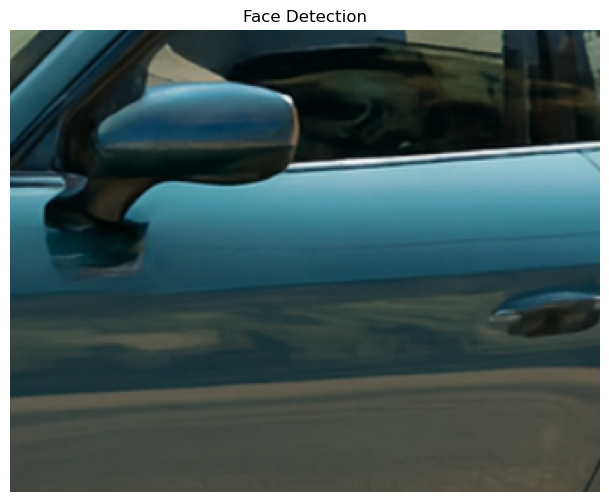

In [2]:
import cv2
import matplotlib.pyplot as plt

# Load Haar Cascade
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# Load image
image = cv2.imread(
    r"C:\Users\vatap\OneDrive\Pictures\car.png.png"
)

if image is None:
    print("Image not found!")
else:
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    print("Number of faces detected:", len(faces))

    # Draw rectangles
    for (x, y, w, h) in faces:
        cv2.rectangle(
            image,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

    # Convert BGR to RGB
    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # Display result
    plt.figure(figsize=(8, 6))
    plt.imshow(image_rgb)
    plt.title("Face Detection")
    plt.axis("off")
    plt.show()

In [1]:
import os

print(os.path.exists(r"C:\cvip\deploy.prototxt"))
print(os.path.exists(r"C:\cvip\res10_300x300_ssd_iter_140000_fp16.caffemodel"))

False
False


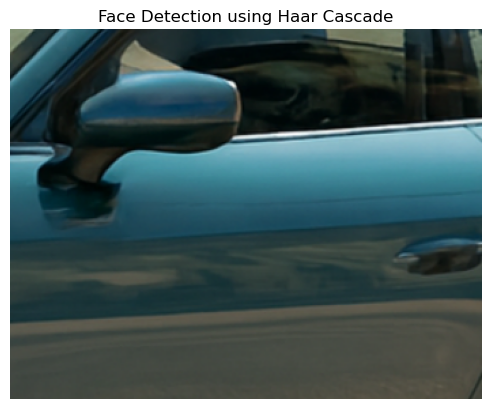

In [2]:
import cv2
import matplotlib.pyplot as plt

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

image = cv2.imread(
    r"C:\Users\vatap\OneDrive\Pictures\car.png.png"
)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray, 1.1, 5)

for (x, y, w, h) in faces:
    cv2.rectangle(image, (x, y), (x+w, y+h), (0,255,0), 2)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis("off")
plt.title("Face Detection using Haar Cascade")
plt.show()

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV Version:", cv2.__version__)

OpenCV Version: 4.10.0


In [4]:
import os

print(os.path.exists(r"C:\cvip\deploy.prototxt"))
print(os.path.exists(r"C:\cvip\res10_300x300_ssd_iter_140000_fp16.caffemodel"))
print(os.path.exists(r"C:\cvip\india.jpg"))

False
False
False


Faces Detected: 0


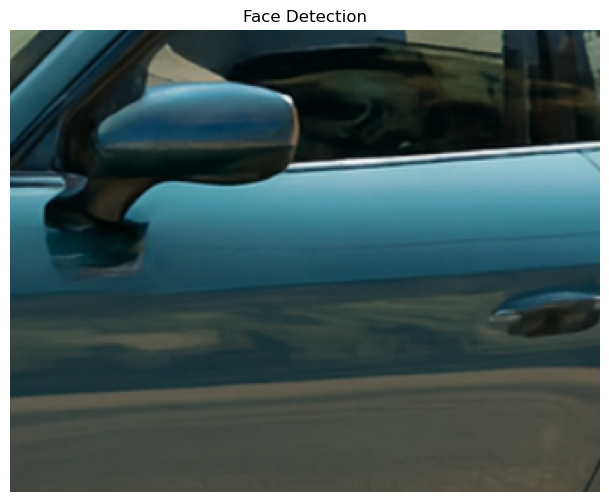

In [5]:
import cv2
import matplotlib.pyplot as plt

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

image = cv2.imread(
    r"C:\Users\vatap\OneDrive\Pictures\car.png.png"
)

if image is None:
    print("Image not found")
else:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5
    )

    print("Faces Detected:", len(faces))

    for (x, y, w, h) in faces:
        cv2.rectangle(
            image,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(8, 6))
    plt.imshow(image_rgb)
    plt.title("Face Detection")
    plt.axis("off")
    plt.show()

Decision Tree Classifier Evaluation:
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



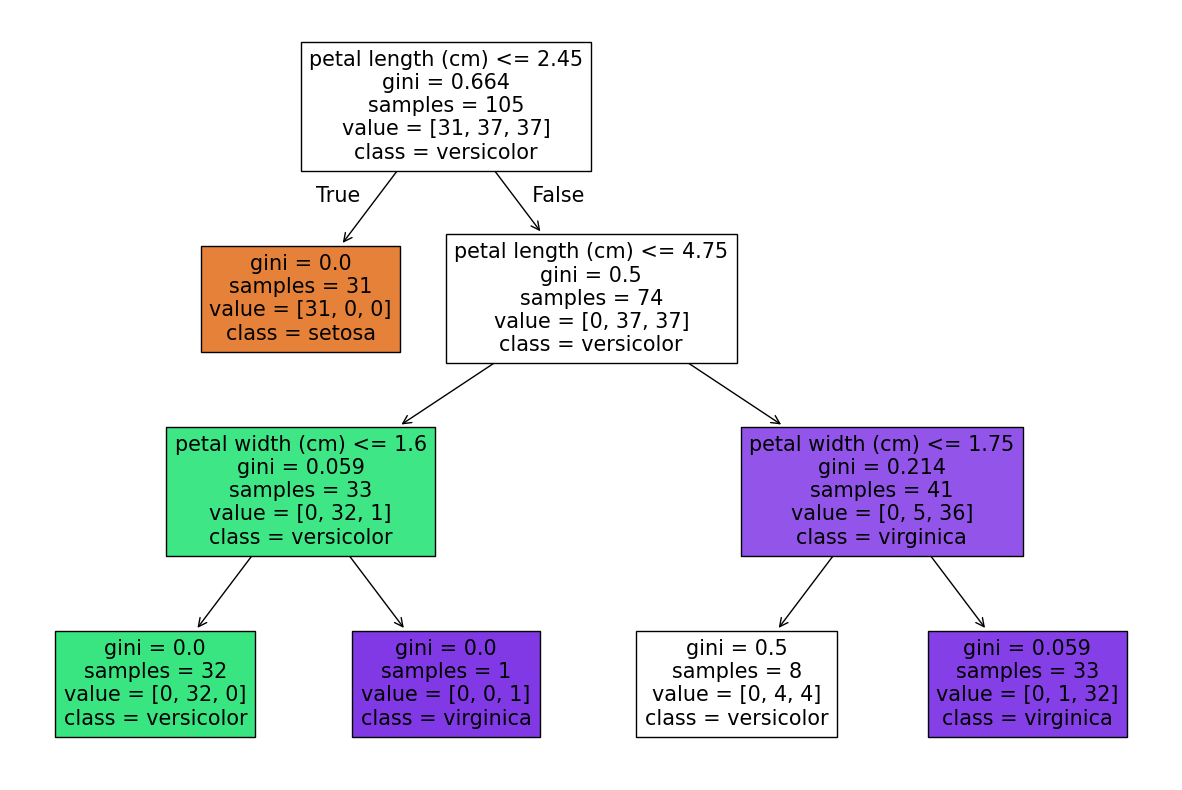

In [6]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# 1. Load Iris Dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Create and train Decision Tree model
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# 4. Make predictions
y_pred = clf.predict(X_test)

# 5. Evaluate the model
print("Decision Tree Classifier Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

# 6. Visualize Decision Tree
plt.figure(figsize=(15, 10))
plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)
plt.show()

In [7]:
# Import required libraries
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.datasets import load_breast_cancer

# Load Breast Cancer Dataset
data = load_breast_cancer()

# Features (X) and Target (y)
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create Logistic Regression Model
model = LogisticRegression(
    solver='liblinear',
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.956140350877193

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Confusion Matrix:
[[39  4]
 [ 1 70]]


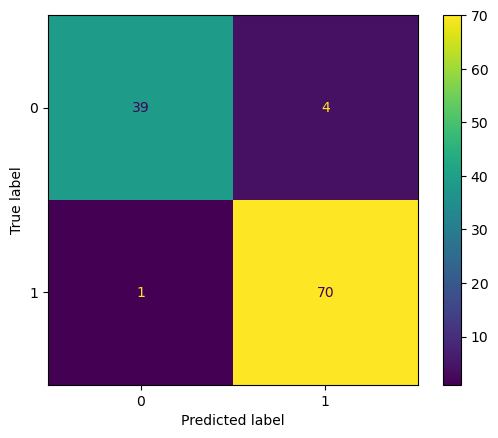

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.show()